## SETUP

In [ ]:
from pathlib import Path

import pandas as pd
import tensorflow as tf
import yaml
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC, BinaryAccuracy, Precision, Recall
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)

from breast_cancer.data import optimize_dataset, prepare_dataset
from breast_cancer.models import build_from_config
from breast_cancer.utils import get_save_path
from breast_cancer.train import train_model
from breast_cancer.utils.plots import plot_history

2025-09-21 10:58:18.319552: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-21 10:58:18.393390: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-21 10:58:18.411551: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-21 10:58:18.743861: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvi

In [2]:
# Check installed tensorflow version
print(f"Tensorflow version: {tf.__version__}")

# Check GPU availability
print(f"GPU List: {tf.config.list_physical_devices('GPU')}")

Tensorflow version: 2.10.1
GPU List: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Import general configurations
with open("../configs/default.yml") as f:
    default_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import training configurations
with open("../configs/training.yml") as f:
    training_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import model configurations
with open("../configs/model_cnn_elhouby.yml") as f:
    model_cfg = yaml.load(f, Loader=yaml.FullLoader)

In [4]:
dir_data_split = Path(default_cfg["dirs"]["data_split"])
dir_data_split.mkdir(exist_ok=True)

dir_model_logs = Path(default_cfg["dirs"]["model_logs"])
dir_model_logs.mkdir(exist_ok=True)

dir_model_initial = Path(default_cfg["dirs"]["model_initial"])
dir_model_initial.mkdir(exist_ok=True)

In [5]:
def get_dataset(image_paths, image_labels, image_resize, dataset_cfg):
    if isinstance(image_resize, int):
        image_resize = (image_resize, image_resize)
    dataset = prepare_dataset(image_paths, image_labels, image_resize)
    dataset = optimize_dataset(dataset, **dataset_cfg)
    return dataset

In [6]:
# Set random seeds
tf.random.set_seed(default_cfg["random_seed"])

In [7]:
EPOCHS = 50

## MODEL STARTING POINT

In [8]:
# Build model from spec
model = build_from_config(model_cfg["model_args"])
model.summary()

# Save initial weights for multiple training configurations
save_path = get_save_path(default_cfg["dirs"]["model_initial"], f"{model.name}", "")
model.save_weights(save_path)
print(f"Model initial weights are saved at {save_path}")

Model: "cnn_baseline"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 1)]     0         
                                                                 
 conv2d (Conv2D)             (None, 252, 252, 16)      416       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 126, 126, 16)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 122, 122, 16)      6416      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 61, 61, 16)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 61, 61, 14)       

2025-09-21 10:58:19.642208: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-21 10:58:19.748763: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22177 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:02:00.0, compute capability: 8.9


## MODEL EXPLORATION

#### Split by Image ID

In [9]:
df_train_image_random = pd.read_csv(dir_data_split / "train_image_random_aug.csv") # get the augmented version
df_val_image_random = pd.read_csv(dir_data_split / "val_image_random.csv")

df_train_image_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-7


In [10]:
ds_train_image_random = get_dataset(
    df_train_image_random["augmented"].values,
    df_train_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
)

ds_val_image_random = get_dataset(
    df_val_image_random["processed"].values,
    df_val_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["test"],
)

In [ ]:
# Load the model
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [12]:
# Train model
history_image = model.fit(
    ds_train_image_random,
    validation_data=ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/50


2025-09-21 10:58:23.750785: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8905
2025-09-21 10:58:23.809569: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 10:58:24.116157: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 10:58:24.116185: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2025-09-21 10:58:24.116728: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 10:58:24.116781: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2025-09-21 10:58:24.192239: I tensorflow/stream_executor/cuda/c

323/323 [==============================] - 13s 27ms/step - loss: 0.3864 - auc: 0.8959 - binary_accuracy: 0.8277 - precision: 0.7652 - recall: 0.8402 - val_loss: 1.0131 - val_auc: 0.5714 - val_binary_accuracy: 0.4119 - val_precision: 0.4119 - val_recall: 1.0000 - lr: 1.0000e-04
Epoch 2/50
323/323 [==============================] - 9s 27ms/step - loss: 0.4480 - auc: 0.8689 - binary_accuracy: 0.7838 - precision: 0.7109 - recall: 0.8021 - val_loss: 0.9404 - val_auc: 0.5706 - val_binary_accuracy: 0.4119 - val_precision: 0.4119 - val_recall: 1.0000 - lr: 1.0000e-04
Epoch 3/50
323/323 [==============================] - 6s 17ms/step - loss: 0.4785 - auc: 0.8433 - binary_accuracy: 0.7373 - precision: 0.7269 - recall: 0.5818 - val_loss: 1.0092 - val_auc: 0.5619 - val_binary_accuracy: 0.4119 - val_precision: 0.4119 - val_recall: 1.0000 - lr: 1.0000e-04
Epoch 4/50
323/323 [==============================] - 9s 26ms/step - loss: 0.5305 - auc: 0.8009 - binary_accuracy: 0.7167 - precision: 0.6532 - re

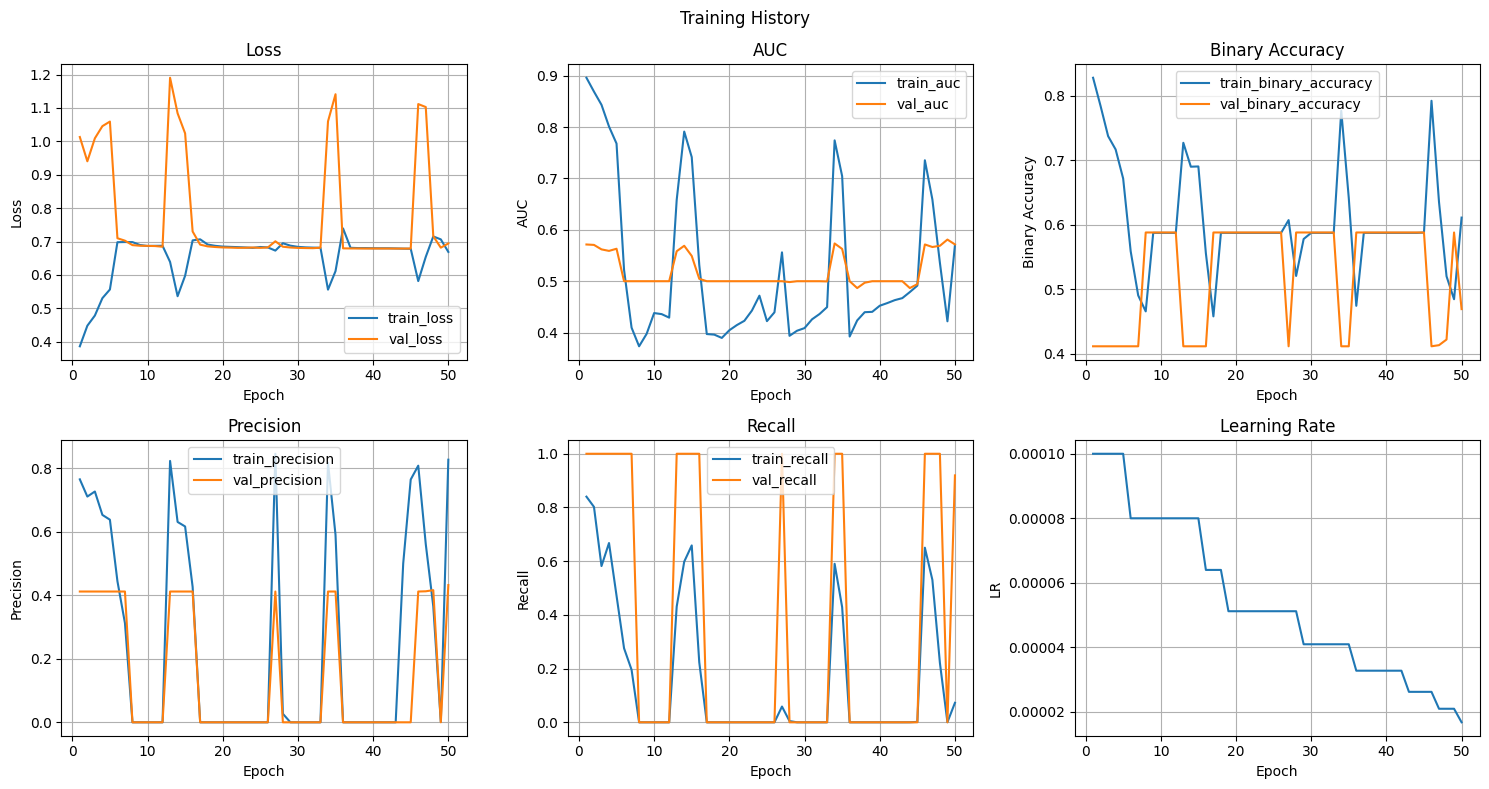

In [13]:
plot_history(history_image)

In [14]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_image_random.csv")
Path(logger_path).parent.mkdir(exist_ok=True)

pd.DataFrame(history_image.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/cnn_baseline/initial_cnn_baseline_image_random.csv'

#### Split by Patient ID

In [15]:
df_train_patient_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_patient_random = pd.read_csv(dir_data_split / "val_patient_random.csv")

df_train_patient_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-7


In [16]:
ds_train_patient_random = get_dataset(
    df_train_patient_random["augmented"].values,
    df_train_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
)

ds_val_patient_random = get_dataset(
    df_val_patient_random["processed"].values,
    df_val_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["test"],
)

In [17]:
# Train model
history_patient = model.fit(
    ds_train_patient_random,
    validation_data=ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/50
316/316 [==============================] - 7s 21ms/step - loss: 0.6964 - auc: 0.3798 - binary_accuracy: 0.5428 - precision: 0.0019 - recall: 2.4474e-04 - val_loss: 0.6731 - val_auc: 0.5326 - val_binary_accuracy: 0.6045 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.6777e-05
Epoch 2/50
316/316 [==============================] - 9s 27ms/step - loss: 0.6753 - auc: 0.4944 - binary_accuracy: 0.5961 - precision: 0.9000 - recall: 0.0011 - val_loss: 0.6730 - val_auc: 0.4993 - val_binary_accuracy: 0.6045 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.6777e-05
Epoch 3/50
316/316 [==============================] - 6s 18ms/step - loss: 0.6745 - auc: 0.5051 - binary_accuracy: 0.5961 - precision: 0.7500 - recall: 0.0015 - val_loss: 0.6729 - val_auc: 0.5000 - val_binary_accuracy: 0.6045 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.6777e-05
Epoch 4/50
316/316 [==============================] - 9s 27ms/step - loss: 0.6741 - auc: 0.5075 - binary_acc

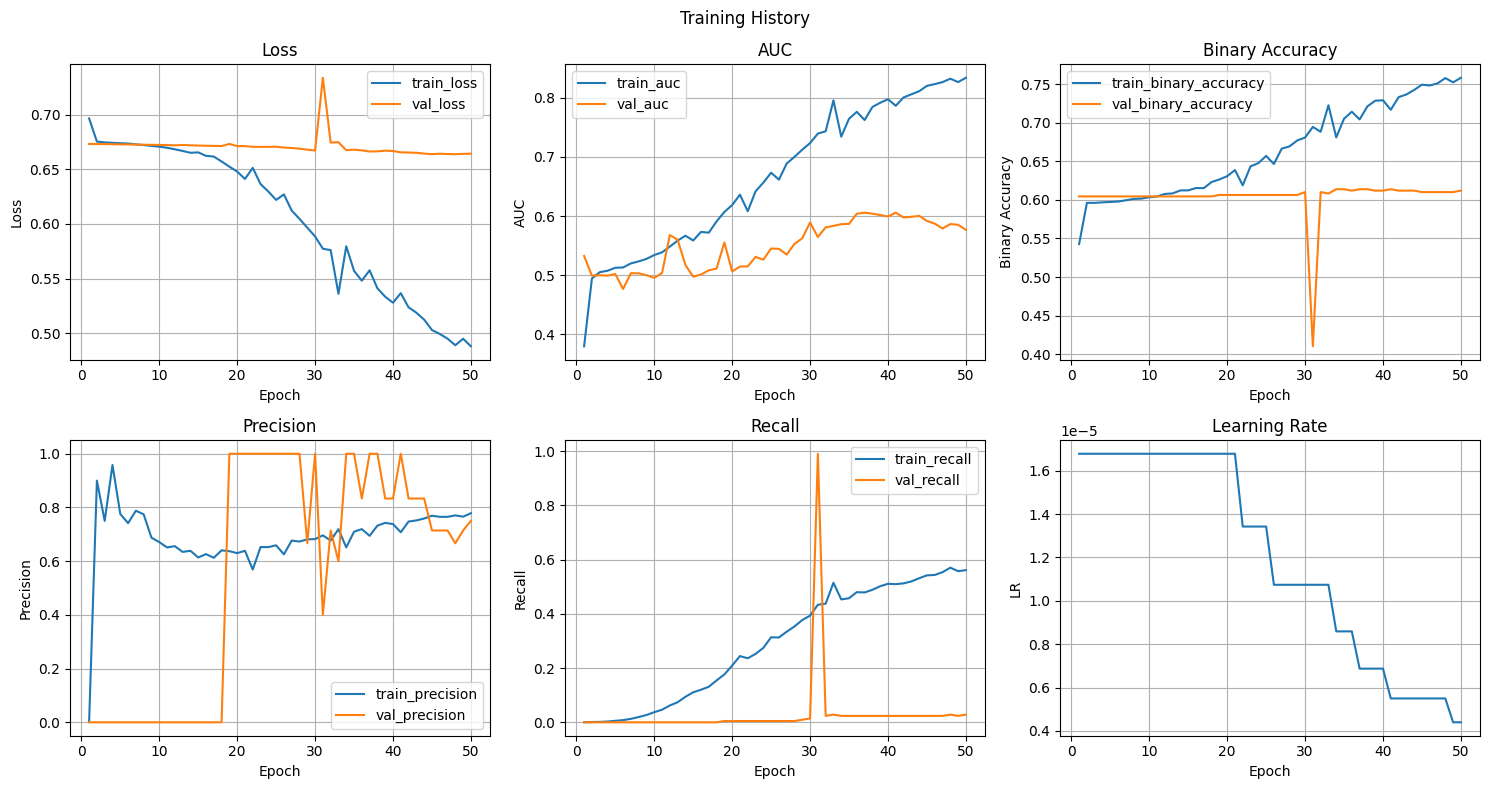

In [18]:
plot_history(history_patient)

In [19]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_patient_random.csv")

pd.DataFrame(history_patient.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/cnn_baseline/initial_cnn_baseline_patient_random.csv'